# **Title: "Characterizing Sequence-Function Relationships in Chimeric DcuS/EnvZ Histidine Kinases"**  
  
## Authors: <font color="blue">Luca B. Lippert, <font color="black"> Samuel R. Hinton, Andrew Holston, Karl J. Romanowicz, Calin Plesa

Provides reproducible analysis for *Association of mutant sequence, barcode, and inferred fluorescence phenotype* in the following manuscript:  
     
Citation: Lippert LB, Hinton SR, Holston A, Romanowicz KJ, Plesa C. Characterizing Sequence-Function Relationships in Chimeric DcuS/EnvZ Histidine Kinases. *In Prep.* 2026.  
  
GitHub Repository: https://github.com/PlesaLab/DcuSEnvZ  

## **Experiment**

This pipeline processes the .fcs files collected from the FACS experiments run on synTCS-MutLib grown without ligand, 20 mM fumarate, and 20 mM aspartate. The files are read-in, converted to molecules of equivalent fluorescein (MEFL) with a built-in conversion function from FlowCal, a subpopulation is sized selected with a built-in ellipse gate in FlowCal, then the bin population fractions are calculated using the previously recorded bin boundaries.  

The following Python packages must be installed prior to loading into the Jupyter Notebook session. See the Reproducibility section below for a complete list of packages and their versions used in this workflow. 

In [25]:
import FlowCal as fc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

First, we will define a useful function which will read-in, visualize our rainbow calibration beads populations, and return the MEFL conversion function. Note that this process is done for two batches of rainbow calibration beads, as the samples were sorted on different days. 

In [3]:
def rainbow_beads(fcs_file):
    # read in the FCS file for rainbow beads
    b = fc.io.FCSData(fcs_file)
    b = fc.transform.to_rfi(b)
    
    #gate the data based on density, retain 30% of the datapoints 
    density_gate_output = fc.gate.density2d(b,
                                        channels=['FSC-A','SSC-A'],
                                        gate_fraction=0.3,
                                        full_output=True)
    b_g = density_gate_output.gated_data
    c = density_gate_output.contour
    
    #plot the data
    fc.plot.density_and_hist(b, 
                         gated_data=b_g,
                         gate_contour=c,
                         density_channels=['FSC-A','SSC-A'],
                         density_params={'mode':'scatter',
                                         'xlim':[1e4,1e6],
                                         'ylim':[1e5,1e6],
                                         'sigma' : 5.},
                         hist_channels=[6])

    plt.tight_layout()
    plt.show()
    
    # generate a standard curve to transform the data into MEF values
    mefl_values = np.array([0, 792, 2079, 6588, 16471, 47497, 137049, 271647])
    to_mef = fc.mef.get_transform_fxn(b_g,
                                  mef_values=mefl_values,
                                  mef_channels='488-1  530_30-A',
                                  plot=True)
    plt.show()
    return to_mef

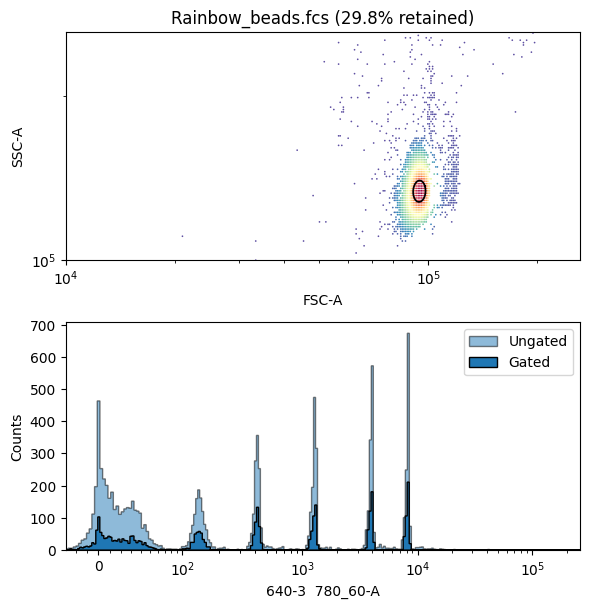

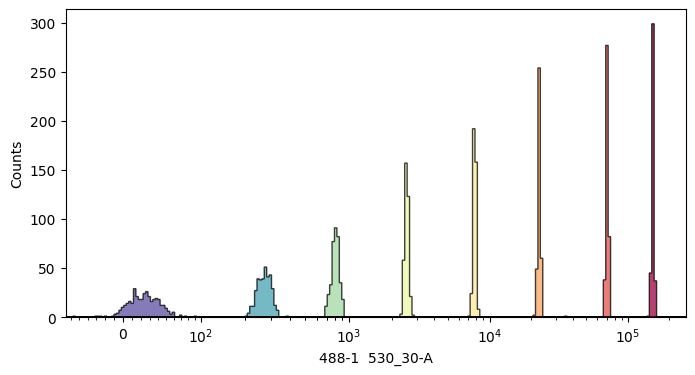

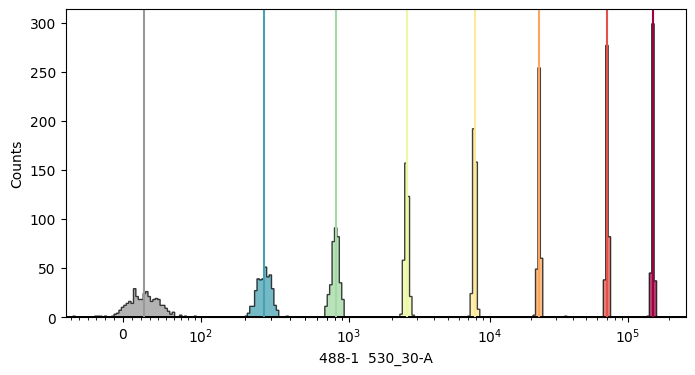

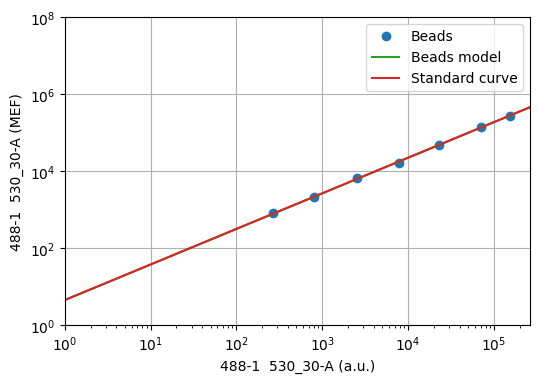

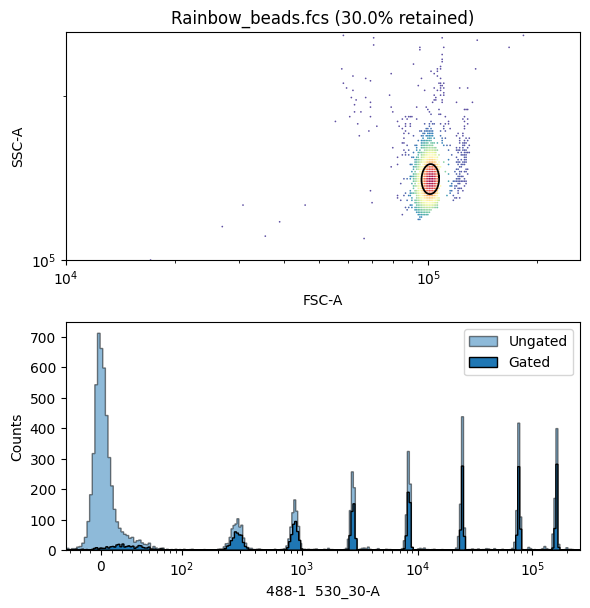

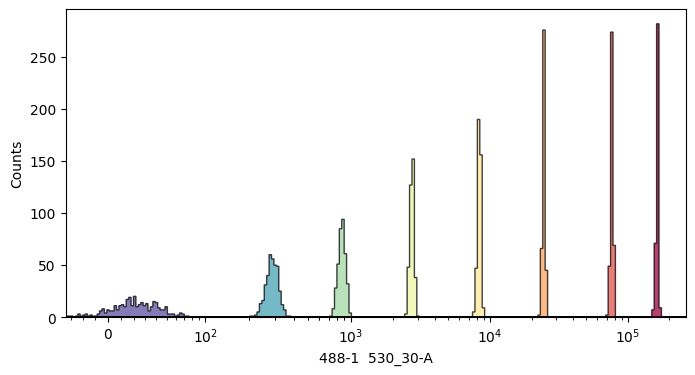

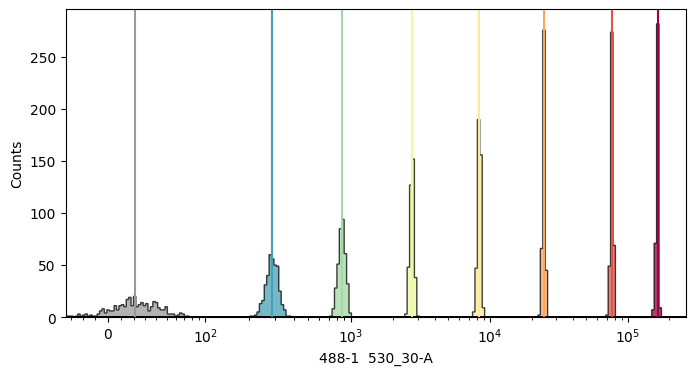

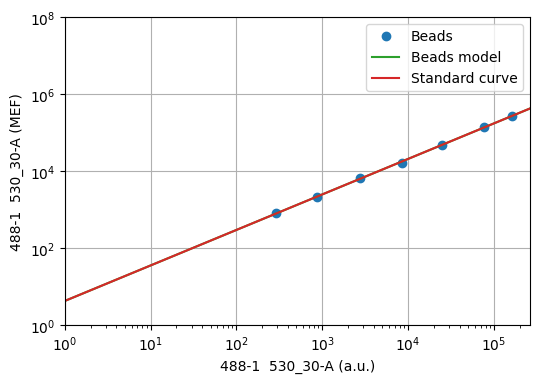

In [4]:
r1 = rainbow_beads('2025-05-01/2/Rainbow_beads.fcs') # Rainbow calibration beads for No Ligand sample
r2 = rainbow_beads('2025-05-13/Rainbow_beads.fcs')   # Rainbow calibration beads for Fumarate and Aspartate samples

Next, we will define another function which will read-in the .fcs files containing our population data, convert from relative fluorescence units to MEFL, gate the population to keep a subset of events which correspond to the cells which we size-selected during the sort, and plot the resultant population size scatter plot and fluorescence distribution. 

In [5]:
def rgp(fcs_file, mef_curve):
    data = fc.io.FCSData(fcs_file)
    data_rfi = fc.transform.to_rfi(data)
    data_mef = mef_curve(data_rfi, channels='488-1  530_30-A')
    data_hlg = fc.gate.high_low(data_mef, channels=['FSC-A', 'SSC-A'])
    
    plt.figure()
    s_g3 = fc.gate.ellipse(data_hlg,
                             channels=['FSC-A', 'SSC-A'],
                             log=True,
                             center=(3.5, 3.5),
                             a=0.3,
                             b=0.2,
                             theta=30/180.*np.pi)
    fc.plot.density2d(s_g3,
                        channels=['FSC-A', 'SSC-A'],
                        mode='scatter')
    
    plt.figure()
    fc.plot.hist1d(s_g3, channel='488-1  530_30-A')
    title_str = "ellipse gated data, %s"%(fcs_file)
    plt.title(title_str)
    plt.tight_layout()
    plt.show()
    plt.close()
    
    return s_g3

No Ligand:

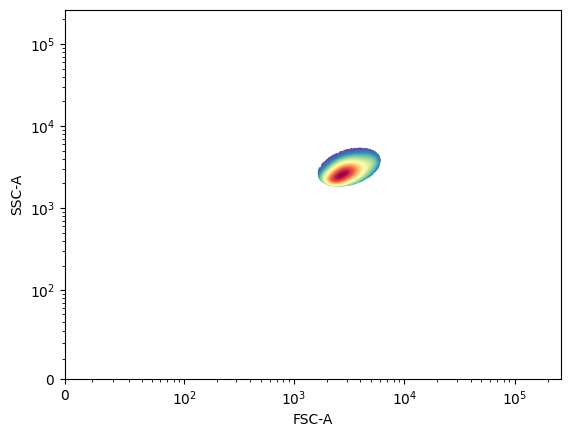

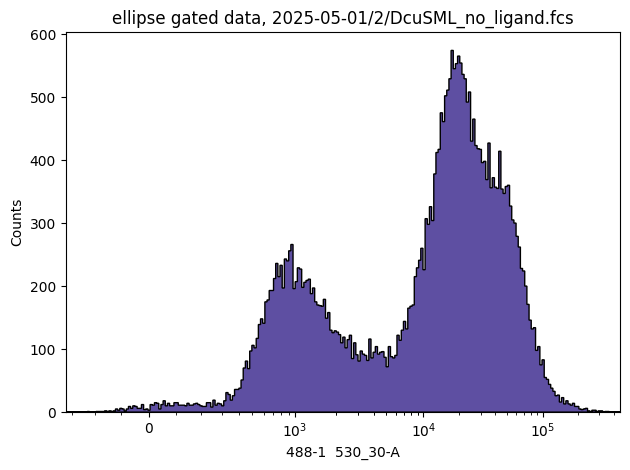

In [7]:
nl = rgp('2025-05-01/2/DcuSML_no_ligand.fcs', r1)

Fumarate:

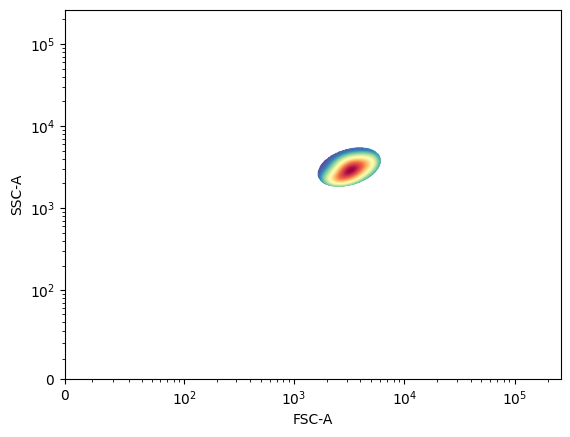

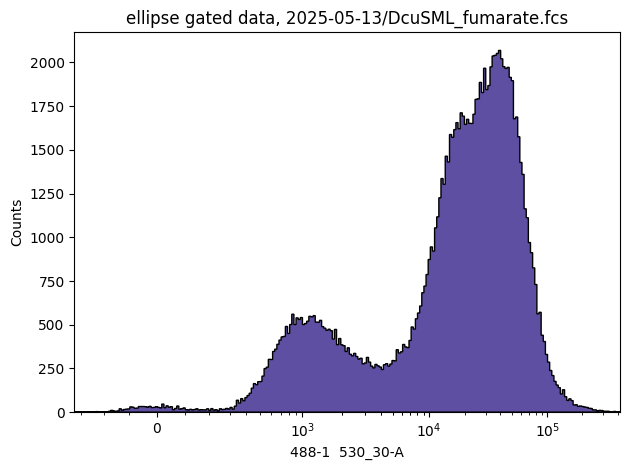

In [8]:
fum = rgp('2025-05-13/DcuSML_fumarate.fcs', r2)

Aspartate:

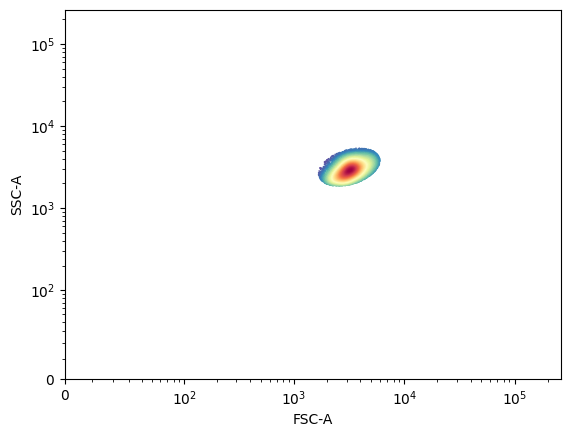

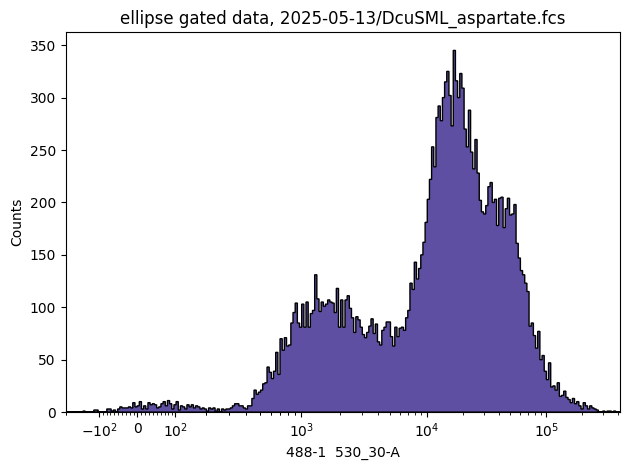

In [9]:
asp = rgp('2025-05-13/DcuSML_aspartate.fcs', r2)

Next, we will perform a similar process on .fcs files containing the bin boundaries in relative fluorescence units, as recorded on the experiment days. 

In [11]:
def rt(fcs_file, mef_curve):
    data = fc.io.FCSData(fcs_file)
    data_rfi = fc.transform.to_rfi(data)
    data_mef = mef_curve(data_rfi, channels='488-1  530_30-A')
    return data_mef

bins1 = rt('bins_new.fcs', r1)
bins2 = rt('bins_new.fcs', r2)

Here, we will export the MEFL bin boundaries as a .tsv file to read-in to an R session later on. 

In [12]:
def fcs_to_tsv(fcs_file, output_file):
    fcs_retain = fcs_file[:,['488-1  530_30-A']]
    df = pd.DataFrame(fcs_retain, columns=fcs_retain.channels)
    tsv_file = df.to_csv(output_file, sep="\t", index=True)
    return tsv_file

bins1 = fcs_to_tsv(bins1, 'bins1.tsv')
bins2 = fcs_to_tsv(bins2, 'bins2.tsv')

We will use the .tsv file version of the bin boundaries for easier parsing:

In [13]:
bins1_df = pd.read_csv("bins1.tsv", delimiter="\t")
bins2_df = pd.read_csv("bins2.tsv", delimiter="\t")

Next, we need to subset all three dataframes to keep the same amount of events from each. Here, we will select out 10,000 random events. 

In [14]:
def normalize_to_mode(list_of_samples):
    counts_list = [sample.shape[0] for sample in list_of_samples]
    minimum = 10000
    
    fra_list = [minimum/count for count in counts_list]

    def random_subset(data, keep_frac, seed=None):
        rng = np.random.default_rng(seed)  # reproducible if seed is set
        n = data.shape[0]
    
        n_keep = int(n * keep_frac)
        indices = rng.choice(n, size=n_keep, replace=False)
    
        return data[indices]

    subset_list = [random_subset(fcs_file, fra) for fcs_file, fra in zip(list_of_samples, fra_list)]
    
    return subset_list

NL_10000, F_10000, A_10000 = normalize_to_mode([nl, fum, asp])

Before we calculate the bin population fractions, we will visualize what the flow cytometry data looks like first. 

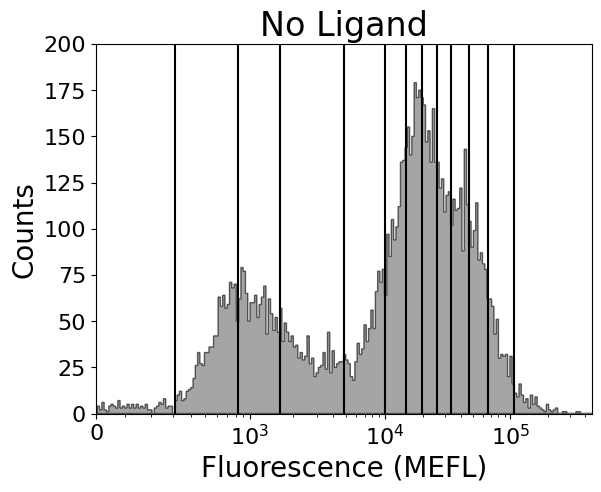

In [16]:
plt.figure()
fc.plot.hist1d(NL_10000, channel='488-1  530_30-A', alpha=0.6, xlim=(0,1000000), ylim=(0,200), facecolor="dimgray", edgecolor="k")

plt.axvline(bins1_df.iloc[0,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[1,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[2,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[3,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[4,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[5,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[6,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[7,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[8,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[9,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[10,1], linestyle="-", color="k")
plt.axvline(bins1_df.iloc[11,1], linestyle="-", color="k")

plt.tick_params(axis='both', which='major', labelsize=16)

plt.xlabel('Fluorescence (MEFL)', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.title('No Ligand', fontsize=24)
plt.show()

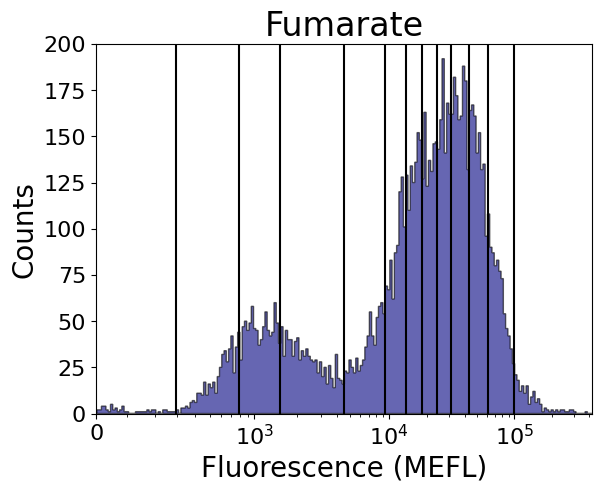

In [17]:
plt.figure()
fc.plot.hist1d(F_10000, channel='488-1  530_30-A', alpha=0.6, xlim=(0,1000000), ylim=(0,200), facecolor="navy", edgecolor="k")

plt.axvline(bins2_df.iloc[0,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[1,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[2,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[3,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[4,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[5,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[6,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[7,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[8,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[9,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[10,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[11,1], linestyle="-", color="k")

plt.tick_params(axis='both', which='major', labelsize=16)

plt.xlabel('Fluorescence (MEFL)', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.title('Fumarate', fontsize=24)
plt.show()

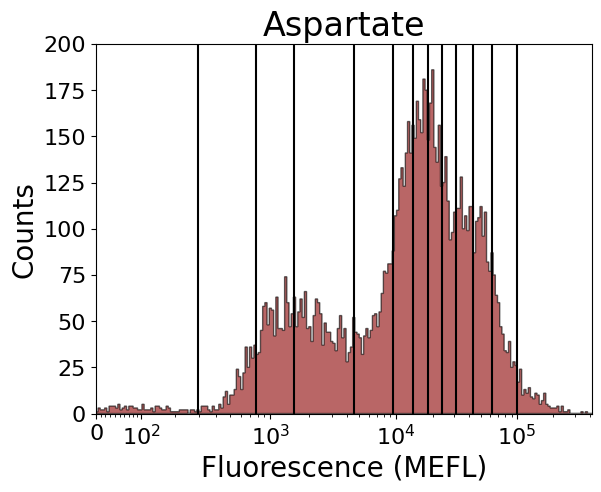

In [18]:
plt.figure()
fc.plot.hist1d(A_10000, channel='488-1  530_30-A', alpha=0.6, xlim=(0,1000000), ylim=(0,200), facecolor="darkred", edgecolor="k")

plt.axvline(bins2_df.iloc[0,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[1,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[2,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[3,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[4,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[5,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[6,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[7,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[8,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[9,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[10,1], linestyle="-", color="k")
plt.axvline(bins2_df.iloc[11,1], linestyle="-", color="k")

plt.tick_params(axis='both', which='major', labelsize=16)

plt.xlabel('Fluorescence (MEFL)', fontsize=20)
plt.ylabel('Counts', fontsize=20)

plt.title('Aspartate', fontsize=24)
plt.show()

Finally, let's define a function which will use the bin boundaries as categories with which to count events for. Briefly, this function will iterate over the inputted .fcs file, count the number of events from the green fluorescence (MEFL) channel that appear in each of the twelve bins, then print out the fraction of the population that each bin represents. We will later use these fractions to normalize Flow-seq data in the Rmarkdown scripts: *"Barcode_Counts_to_Median_Bin"*

In [19]:
def calc_pct_pop(fcs_file, bins_df):
    bin1_lower_lim = bins_df.iloc[0,1]
    bin2_lower_lim = bins_df.iloc[1,1]
    bin3_lower_lim = bins_df.iloc[2,1]
    bin4_lower_lim = bins_df.iloc[3,1]
    bin5_lower_lim = bins_df.iloc[4,1]
    bin6_lower_lim = bins_df.iloc[5,1]
    bin7_lower_lim = bins_df.iloc[6,1]
    bin8_lower_lim = bins_df.iloc[7,1]
    bin9_lower_lim = bins_df.iloc[8,1]
    bin10_lower_lim = bins_df.iloc[9,1]
    bin11_lower_lim = bins_df.iloc[10,1]
    bin12_lower_lim = bins_df.iloc[11,1]
    
    total_pop, bin1_pop, bin2_pop, bin3_pop, bin4_pop, bin5_pop, bin6_pop, bin7_pop, bin8_pop, bin9_pop, bin10_pop, bin11_pop, bin12_pop = [], [], [], [], [], [], [], [], [], [], [], [], []
    
    for channel in fcs_file.channels:
        if channel == "488-1  530_30-A":
            idx = fcs_file.channels.index("488-1  530_30-A")
            
            for event in fcs_file[:, idx]:
                if event >= bin1_lower_lim:
                    total_pop.append(event)
                    
                if event >= bin1_lower_lim and event < bin2_lower_lim:
                    bin1_pop.append(event)
                    
                if event >= bin2_lower_lim and event < bin3_lower_lim:
                    bin2_pop.append(event)
                    
                if event >= bin3_lower_lim and event < bin4_lower_lim:
                    bin3_pop.append(event)
                    
                if event >= bin4_lower_lim and event < bin5_lower_lim:
                    bin4_pop.append(event)
                    
                if event >= bin5_lower_lim and event < bin6_lower_lim:
                    bin5_pop.append(event)
                    
                if event >= bin6_lower_lim and event < bin7_lower_lim:
                    bin6_pop.append(event)
                    
                if event >= bin7_lower_lim and event < bin8_lower_lim:
                    bin7_pop.append(event)
                    
                if event >= bin8_lower_lim and event < bin9_lower_lim:
                    bin8_pop.append(event)
                    
                if event >= bin9_lower_lim and event < bin10_lower_lim:
                    bin9_pop.append(event)
                    
                if event >= bin10_lower_lim and event < bin11_lower_lim:
                    bin10_pop.append(event)
                    
                if event >= bin11_lower_lim and event < bin12_lower_lim:
                    bin11_pop.append(event)
                    
                if event >= bin12_lower_lim:
                    bin12_pop.append(event)
    
    bin1_frac = len(bin1_pop)/len(total_pop)
    bin2_frac = len(bin2_pop)/len(total_pop)
    bin3_frac = len(bin3_pop)/len(total_pop)
    bin4_frac = len(bin4_pop)/len(total_pop)
    bin5_frac = len(bin5_pop)/len(total_pop)
    bin6_frac = len(bin6_pop)/len(total_pop)
    bin7_frac = len(bin7_pop)/len(total_pop)
    bin8_frac = len(bin8_pop)/len(total_pop)
    bin9_frac = len(bin9_pop)/len(total_pop)
    bin10_frac = len(bin10_pop)/len(total_pop)
    bin11_frac = len(bin11_pop)/len(total_pop)
    bin12_frac = len(bin12_pop)/len(total_pop)
    
    print("Total population:",len(total_pop))
    print("Bin 1 population:", len(bin1_pop), "Bin 1 fraction:", bin1_frac)
    print("Bin 2 population:", len(bin2_pop), "Bin 2 fraction:", bin2_frac)
    print("Bin 3 population:", len(bin3_pop), "Bin 3 fraction:", bin3_frac)
    print("Bin 4 population:", len(bin4_pop), "Bin 4 fraction:", bin4_frac)
    print("Bin 5 population:", len(bin5_pop), "Bin 5 fraction:", bin5_frac)
    print("Bin 6 population:", len(bin6_pop), "Bin 6 fraction:", bin6_frac)
    print("Bin 7 population:", len(bin7_pop), "Bin 7 fraction:", bin7_frac)
    print("Bin 8 population:", len(bin8_pop), "Bin 8 fraction:", bin8_frac)
    print("Bin 9 population:", len(bin9_pop), "Bin 9 fraction:", bin9_frac)
    print("Bin 10 population:", len(bin10_pop), "Bin 10 fraction:", bin10_frac)
    print("Bin 11 population:", len(bin11_pop), "Bin 11 fraction:", bin11_frac)
    print("Bin 12 population:", len(bin12_pop), "Bin 12 fraction:", bin12_frac)
    
    all_frac = [bin1_frac, bin2_frac, bin3_frac, bin4_frac, bin5_frac, bin6_frac, bin7_frac, bin8_frac, bin9_frac, bin10_frac, bin11_frac, bin12_frac]
    
    return all_frac

In [20]:
NL_fracs = calc_pct_pop(NL_10000, bins1_df)

Total population: 9838
Bin 1 population: 992 Bin 1 fraction: 0.10083350274446026
Bin 2 population: 1061 Bin 2 fraction: 0.10784712339906485
Bin 3 population: 934 Bin 3 fraction: 0.09493799552754625
Bin 4 population: 791 Bin 4 fraction: 0.08040252083756862
Bin 5 population: 999 Bin 5 fraction: 0.10154502947753609
Bin 6 population: 1135 Bin 6 fraction: 0.1153689774344379
Bin 7 population: 961 Bin 7 fraction: 0.09768245578369587
Bin 8 population: 778 Bin 8 fraction: 0.07908111404757065
Bin 9 population: 873 Bin 9 fraction: 0.08873754828217117
Bin 10 population: 763 Bin 10 fraction: 0.0775564139052653
Bin 11 population: 433 Bin 11 fraction: 0.044013010774547674
Bin 12 population: 118 Bin 12 fraction: 0.011994307786135394


In [21]:
F_fracs = calc_pct_pop(F_10000, bins2_df)

Total population: 9904
Bin 1 population: 447 Bin 1 fraction: 0.04513327948303716
Bin 2 population: 830 Bin 2 fraction: 0.08380452342487883
Bin 3 population: 834 Bin 3 fraction: 0.08420840064620355
Bin 4 population: 668 Bin 4 fraction: 0.06744749596122779
Bin 5 population: 854 Bin 5 fraction: 0.08622778675282713
Bin 6 population: 920 Bin 6 fraction: 0.09289176090468497
Bin 7 population: 890 Bin 7 fraction: 0.0898626817447496
Bin 8 population: 1034 Bin 8 fraction: 0.10440226171243942
Bin 9 population: 1299 Bin 9 fraction: 0.13115912762520193
Bin 10 population: 1210 Bin 10 fraction: 0.12217285945072698
Bin 11 population: 745 Bin 11 fraction: 0.0752221324717286
Bin 12 population: 173 Bin 12 fraction: 0.017467689822294023


In [22]:
A_fracs = calc_pct_pop(A_10000, bins2_df)

Total population: 9857
Bin 1 population: 339 Bin 1 fraction: 0.03439180277975043
Bin 2 population: 877 Bin 2 fraction: 0.088972303946434
Bin 3 population: 1290 Bin 3 fraction: 0.130871461905245
Bin 4 population: 972 Bin 4 fraction: 0.09861012478441716
Bin 5 population: 1195 Bin 5 fraction: 0.12123364106726184
Bin 6 population: 1127 Bin 6 fraction: 0.11433499036217916
Bin 7 population: 955 Bin 7 fraction: 0.0968854621081465
Bin 8 population: 728 Bin 8 fraction: 0.0738561428426499
Bin 9 population: 851 Bin 9 fraction: 0.08633458455919651
Bin 10 population: 818 Bin 10 fraction: 0.08298670995231815
Bin 11 population: 513 Bin 11 fraction: 0.052044232525109056
Bin 12 population: 192 Bin 12 fraction: 0.019478543167292278


# Reproducibility

In [29]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("MatPlotLib:", matplotlib.__version__)
print("FlowCal:", fc.__version__)

NumPy: 1.26.4
Pandas: 2.3.3
MatPlotLib: 3.5.3
FlowCal: 1.3.1
